## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Leann Vo

**Date:** 10/1/2026

#**Q1.**
##1. What is the difference between regression and classification?
Regression predicts a numerical outcome (like sales or prices) while classification predicts a category (like class).

##2. What is a confusion table? What does it help us understand about a model's performance?
A confusion table or matrix compares the numbers of predictions by actual class to predicted class. It will show true positives or negatives and false positives or negatives which helps us figure out what type of errors the model makes.

##3. What does the SSE quantify about a particular model?
SSE (Sum of Squared Error) quantifies how far a model's predictions are from the actual observed values. A lower validation SSE would mean smaller errors in the validation set.

##4. What are overfitting and underfitting?
Overfitting is when a model is too complex so it will pick up the patterns in the training data but will fail on unseen test data. Very small k can overfit noise in the training data. On the other hand, underfitting is when a model is too simple to capture the patterns in the data and will perform poorly on both training and test data. Very large k can underfit by giving similar predictions for every observation.

##5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
Splitting the data into training and test sets helps us evaluate how well the model predicts unseen observations. Choosing k based on accuracy or SSE helps us pick a model that generalizes better overall. It basically prevents overfitting.

##6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

Class labels are more simple to understand and give a clear answer, but they hide how certain the model is which can be misleading when probabilities are close. On the other hand, probability distributions provide more information about confidence and uncertainty, but because they are more complicated, they often require more steps to be converted into a final class prediction.

#**Q2.**

    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB
None
(338, 4)
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
(169, 3)
(169, 3)
mine_type
2    35
1    35
4    33
5    33
3    33
Name: count, dtype: int64
mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64
Best k: 2
Best validation accuracy: 0.46745562130177515
Accuracy: 0.46745562130177515


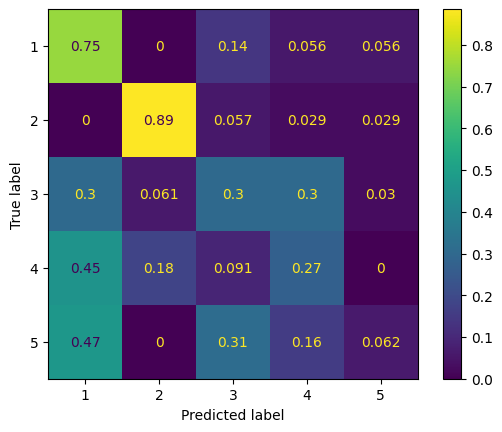

In [22]:
import pandas as pd

# 1. Load data, EDA, summarize target label and features
df = pd.read_csv('land_mines.csv')
print(df.head())
print(df.info())
print(df.shape)
# Summarize mine_type
print(df['mine_type'].value_counts())
# Look at features: voltage, height, soil
df[['voltage','height','soil']].describe()

# The dataset has 338 observations with three predictor variables: voltage, height, and soil, and one target label: mine_type.
# There are no missing variables and the 5 mine types are somewhat evenly represented. The voltage has a mean of 0.43, 0.51 for height, and 0.50 for soil.

# 2. Split sample 50/50 into training and test/validation sets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
eval_X_raw = df[['voltage','height','soil']]
eval_y = df['mine_type']
(
    eval_X_train_raw,
    eval_X_valid_raw,
    eval_y_train,
    eval_y_valid,
) = train_test_split(eval_X_raw, eval_y, test_size=0.50, random_state=65, stratify=eval_y)

eval_scaler = MinMaxScaler()
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.transform(eval_X_valid_raw)

# Check size and class counts to make sure they're 50/50
print(eval_X_train_raw.shape)
print(eval_X_valid_raw.shape)
print(eval_y_train.value_counts())
print(eval_y_valid.value_counts())

# 3. k-NN classifier. explain k selection
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1,51)
accuracies = []

for k in k_values:
    classification_model = KNeighborsClassifier(n_neighbors=k).fit(eval_X_train_scaled, eval_y_train)
    classification_y_pred = classification_model.predict(eval_X_valid_scaled)

    accuracy = accuracy_score(eval_y_valid, classification_y_pred)
    accuracies.append(accuracy)

best_k = k_values[accuracies.index(max(accuracies))]
print('Best k:', best_k)
print('Best validation accuracy:', max(accuracies))

# I tested k values 1 to 50 and calculated the validation accuracy for each mode. I picked the k with the highest validation accuracy.
# The best performing model used a k=2 with a validation accuracy of 46.7%.

# 4. Confusion table for optimal model comparing predicted and actual class label on the test set
from sklearn.metrics import ConfusionMatrixDisplay
best_model = KNeighborsClassifier(n_neighbors=best_k).fit(eval_X_train_scaled, eval_y_train)
best_y_pred = best_model.predict(eval_X_valid_scaled)

ConfusionMatrixDisplay.from_predictions(eval_y_valid, best_y_pred, normalize ='true')

accuracy = accuracy_score(eval_y_valid, best_y_pred)
print('Accuracy:', accuracy)

# The optimal kNN model had an overall validation accuracy of 46.7%. The accuracy varied across the different mine types.
# The model classified 1 and 2 somewhat well with about 75% and 89% of those observations correctly identified, but not as well for types 3, 4, and 5 which had correct classifications
# rates of 30%, 27%, and 6.2%, respectively.

# 5. I wouldn't reccomend using this model alone as a sole decision making tool. Although it performed somewhat well for mine types 1 and 2, it did not perform as well for mine types 3, 4, and 5.
# Because some mine types are more frequently misclassified as other types, the model should only be used alongside other tools or human inspection. In practice, predictions for classes with high error percentages should be used with caution
# and the model shouldn't be trusted when the cost of an error could be dangerous.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]